# 2. Data Retrieval `Statsbomb Events Dataset`

In [1]:
# ----------------------------------
# Statsbomb Event Data Retrieval
# ----------------------------------
import sys
import numpy as np
from pathlib import Path
import polars as pl
import math
from IPython.display import display, HTML
pl.Config.set_tbl_rows(2000) # ensure table displays do not truncate when there's a large number of rows

EDA_DIR = Path.cwd()  # should be .../<parent folder name>/eda
PROJECT_ROOT = EDA_DIR.parent # .../<parent folder name>

STATSBOMB_DIR = PROJECT_ROOT / "data" / "Statsbomb" # .../<parent folder name>/data/Statsbomb
EVENTS_PATH = STATSBOMB_DIR / "events.parquet" # .../<parent folder name>/data/Statsbomb/events.parquet

events_scan = pl.scan_parquet(EVENTS_PATH)
events_df = pl.read_parquet(EVENTS_PATH)

## 2.1. Preprocessing: Create Match Results Table

In [2]:
# ----------------------------------
# Create match results table 
# ----------------------------------
match_results = (events_df.filter((pl.col("type") == "Shot") & (pl.col("shot_outcome") == "Goal"))
    .group_by(["match_id", "team"]).agg(pl.len().alias("goals_scored")))
print("MATCH RESULTS shape | rows = (# games)x(# teams):", match_results.shape)

# left join with unique match/team combo to add teams that did not score any goals
all_team_matches = (events_df.select(["match_id", "team"]).unique()) # All team–match combinations observed in events
match_results = (all_team_matches.join(match_results, on=["match_id", "team"], how="left").with_columns(pl.col("goals_scored").fill_null(0)))
print("MATCH RESULTS Shape | rows = (# games)x(2 teams):", match_results.shape)

# ----------------------------------------
# === add match result column ===
# ----------------------------------------
print("\n\n===== MATCH RESULT Counts =====")
match_results = (match_results.with_columns([pl.col("goals_scored").max().over("match_id").alias("goals_max"),pl.col("goals_scored").min().over("match_id").alias("goals_min"),])
    .with_columns(pl.when(pl.col("goals_max") == pl.col("goals_min")).then(pl.lit("Draw"))
        .when(pl.col("goals_scored") == pl.col("goals_max")).then(pl.lit("Win")).otherwise(pl.lit("Loss")).alias("result"))
    .drop(["goals_max", "goals_min"]).sort("match_id"))
# match_results_counts = match_results.group_by("result").agg(pl.len().alias("n")).sort("result")
display(match_results.head(5))
# display(match_results_counts)

# # ----------------------------------------
# # === add aggregate shots column ===
# # ----------------------------------------
# print("\n\n==== TOTAL SHOTS Mean & SD ====")
# team_shots = (events_df.filter(pl.col("type") == "Shot")
#     .group_by(["match_id", "team"]).agg(pl.len().alias("shots"))) # calculate aggregate shots
# df = (match_results.join(team_shots, on=["match_id", "team"], how="left")
#     .with_columns(pl.col("shots").fill_null(0))) # add to df
# # team_match.head(2)
# team_match_counts = df.group_by("result").agg([pl.col("shots").mean().alias("avg_shots"),pl.col("shots").std().alias("std_shots")]).sort("result")
# display(team_match_counts)

# # ----------------------------------------
# # === add Team xG per match column ===
# # ----------------------------------------
# print("\n\n=== EXPECTED GOAL Mean & SD ===")
# # calculate aggregate xG
# team_match_xg = (events_df.filter(pl.col("type") == "Shot")
#     .group_by(["match_id", "team"]).agg(pl.col("shot_statsbomb_xg").sum().alias("xg_for")))
# # join to add column and fill nulls with 0 (teams with 0 shots in a game will have null aggregate xG
# df = df.join(team_match_xg,on=["match_id", "team"],how="left").with_columns(pl.col("xg_for").fill_null(0.0))
# xg_summary = (     # Summary by result
#     df.group_by("result").agg([pl.col("xg_for").mean().alias("avg_xg"),pl.col("xg_for").std().alias("std_xg")]).sort("result"))
# display(xg_summary)


# # ----------------------------------------
# # === Add goal differential === 
# # ----------------------------------------
# df = (df.with_columns([
#         pl.col("goals_scored").cast(pl.Int64).alias("goals_scored_i"),
#         pl.col("goals_scored").cast(pl.Int64).sum().over("match_id").alias("match_total_goals_i"),])
#     .with_columns([
#         (pl.col("match_total_goals_i") - pl.col("goals_scored_i")).alias("goals_conceded"),
#         (pl.col("goals_scored_i") - (pl.col("match_total_goals_i") - pl.col("goals_scored_i"))).alias("goal_diff"),])
#     .drop(["goals_scored_i", "match_total_goals_i"]))

# # ----------------------------------------
# # === Add opponent totals (xg_against, shots_against) and differentials (xg_diff, shot_diff) === 
# # ----------------------------------------
# df = (
#     df
#     .with_columns(pl.col("shots").cast(pl.Int64).alias("shots_i"))
#     .with_columns([                                                                  # totals per team for each match
#         pl.col("xg_for").sum().over("match_id").alias("match_total_xg"),                 # calculate total xg    in match (sum of both teams)
#         pl.col("shots_i").sum().over("match_id").alias("match_total_shots"),])           # calculate total shots in match (sum of both teams)
#     .with_columns([                                                                  # totals against per team
#         (pl.col("match_total_xg") - pl.col("xg_for")).alias("xg_against"),               # xG against    = (total shots - shots for)
#         (pl.col("match_total_shots") - pl.col("shots_i")).alias("shots_against"),])      # shots against = (total xG    - xG    for)
#     .with_columns([                                                                  # differentials per team
#         (pl.col("xg_for") - pl.col("xg_against")).alias("xg_diff"),                  # xG   diff = (total xG    - xG    for)
#         (pl.col("shots_i") - pl.col("shots_against")).alias("shot_diff"),            # shot diff = (total shots - shots for)
#     ])
#     .drop(["shots_i", "match_total_xg", "match_total_shots"])                        # drop temp columns used for calculation
# )

# # ----------------------------------------
# # === Add dribbles/carries/passes/passes_completed for against/for/dff === 
# # ----------------------------------------
# # calculate totals
# extra = (events_df.group_by(["match_id","team"])
#     .agg([
#         # volume
#         (pl.col("type") == "Carry").sum().alias("n_carries"),
#         (pl.col("type") == "Dribble").sum().alias("n_dribbles"),
#         (pl.col("type") == "Pass").sum().alias("n_passes"),
#         # pass completion proxy (StatsBomb uses pass_outcome null for complete)
#         ((pl.col("type") == "Pass") & (pl.col("pass_outcome").is_null())).sum().alias("n_passes_complete"),]))

# # join with main dataframe
# df = df.drop([  # DuplicateError safeguard
#     'n_carries', 'n_dribbles', 'n_passes', 'n_passes_complete', 'pass_completion_rate', 'carries_against', 'dribbles_against', 
#     'passes_against', 'passes_complete_against', 'carry_diff', 'dribble_diff', 'pass_diff', 'pass_complete_diff'], strict=False)
# df = (df.join(extra, on=["match_id","team"], how="left")
#     .with_columns([
#         pl.col("n_carries").fill_null(0),
#         pl.col("n_dribbles").fill_null(0),
#         pl.col("n_passes").fill_null(0),
#         pl.col("n_passes_complete").fill_null(0),
#         (pl.col("n_passes_complete") / pl.when(pl.col("n_passes") > 0).then(pl.col("n_passes")).otherwise(None)).alias("pass_completion_rate"),]))
# # calculate agains/for/diffs and drop unneeded columns 
# df = (df.with_columns([
#         pl.col("n_carries").cast(pl.Int64).alias("n_carries_i"),
#         pl.col("n_dribbles").cast(pl.Int64).alias("n_dribbles_i"),
#         pl.col("n_passes").cast(pl.Int64).alias("n_passes_i"),
#         pl.col("n_passes_complete").cast(pl.Int64).alias("n_passes_complete_i"),])
#     .with_columns([
#         pl.col("n_carries_i").sum().over("match_id").alias("match_total_carries"),
#         pl.col("n_dribbles_i").sum().over("match_id").alias("match_total_dribbles"),
#         pl.col("n_passes_i").sum().over("match_id").alias("match_total_passes"),
#         pl.col("n_passes_complete_i").sum().over("match_id").alias("match_total_passes_complete"),])
#     .with_columns([
#         (pl.col("match_total_carries") - pl.col("n_carries_i")).alias("carries_against"),
#         (pl.col("match_total_dribbles") - pl.col("n_dribbles_i")).alias("dribbles_against"),
#         (pl.col("match_total_passes") - pl.col("n_passes_i")).alias("passes_against"),
#         (pl.col("match_total_passes_complete") - pl.col("n_passes_complete_i")).alias("passes_complete_against"),])
#     .with_columns([
#         (pl.col("n_carries_i") - pl.col("carries_against")).alias("carry_diff"),
#         (pl.col("n_dribbles_i") - pl.col("dribbles_against")).alias("dribble_diff"),
#         (pl.col("n_passes_i") - pl.col("passes_against")).alias("pass_diff"),
#         (pl.col("n_passes_complete_i") - pl.col("passes_complete_against")).alias("pass_complete_diff"),])
#     .drop(["n_carries_i","n_dribbles_i","n_passes_i","n_passes_complete_i",
#         "match_total_carries","match_total_dribbles","match_total_passes","match_total_passes_complete",]))


# # ----------------------------------------
# #  Add Shots on Target 
# # ----------------------------------------

# # set on target shot outcome types and calculate totals
# sot_outcomes = ["Goal","Saved","Saved to Post","Saved Off Target"]
# team_match_sot = (events_df
#     .filter((pl.col("type") == "Shot") &(pl.col("shot_outcome").is_in(sot_outcomes)))
#     .group_by(["match_id", "team"])
#     .agg(pl.len().alias("shots_on_target")))

# # join with main df
# df = df.drop(["shots_on_target", "sot_against", "sot_diff"], strict=False) # DuplicateError safeguard
# df = (df
#     .join(team_match_sot, on=["match_id", "team"], how="left")
#     .with_columns(pl.col("shots_on_target").fill_null(0))) # fill nulls with 0 for teams with no SOTs in a full game

# # add against and diff
# df = df.with_columns([pl.col("shots_on_target").cast(pl.Int64),])
# df = (df
#     .with_columns(pl.col("shots_on_target").sum().over("match_id").alias("match_sot_total"))
#     .with_columns([
#         (pl.col("match_sot_total") - pl.col("shots_on_target")).alias("sot_against"),
#         (pl.col("shots_on_target") - pl.col("match_sot_total") + pl.col("shots_on_target")).alias("sot_diff")])
#     .drop("match_sot_total"))


# # ----------------------------------------
# # Add Pressures per team per match
# # ----------------------------------------
# # calculate totals
# team_match_pressures = (events_df.filter(pl.col("type") == "Pressure").group_by(["match_id", "team"]).agg(pl.len().alias("pressures")))

# # join totals to main df
# df = df.drop(["pressures", "pressure_against", "pressure_diff"], strict=False) # DuplicateError safeguard
# df = (df.join(team_match_pressures, on=["match_id", "team"], how="left")
#     .with_columns(pl.col("pressures").fill_null(0).cast(pl.Int64)))

# # add against and diff
# df = (df.with_columns(pl.col("pressures").sum().over("match_id").alias("match_pressure_total"))
#     .with_columns([
#         (pl.col("match_pressure_total") - pl.col("pressures")).alias("pressure_against"),
#         (pl.col("pressures") - pl.col("match_pressure_total") + pl.col("pressures")).alias("pressure_diff")])
#     .drop("match_pressure_total"))


# # ----------------------------------------
# # Passes and carries ending in final third (x > 80)
# # ----------------------------------------
# # calculate
# team_match_final_third_pass = (events_df
#     .filter((pl.col("type") == "Pass") &(pl.col("pass_end_location_x") > 80))
#     .group_by(["match_id", "team"])
#     .agg(pl.len().alias("final_third_passes")))
# team_match_final_third_carry = (events_df
#     .filter((pl.col("type") == "Carry") &(pl.col("carry_end_location_x") > 80))
#     .group_by(["match_id", "team"])
#     .agg(pl.len().alias("final_third_carries")))

# # join
# df = df.drop(["final_third_passes", "final_third_carries", "final_third_entries"], strict=False) # DuplicateError safeguard
# df = (df
#     .join(team_match_final_third_pass, on=["match_id", "team"], how="left")
#     .join(team_match_final_third_carry, on=["match_id", "team"], how="left")
#     .with_columns([
#         pl.col("final_third_passes").fill_null(0).cast(pl.Int64),
#         pl.col("final_third_carries").fill_null(0).cast(pl.Int64),])
#     .with_columns((pl.col("final_third_passes") + pl.col("final_third_carries")).alias("final_third_entries")))

# # add against and diff
# df = (df
#     .with_columns(pl.col("final_third_entries").sum().over("match_id").alias("match_final_third_total"))
#     .with_columns([
#         (pl.col("match_final_third_total") - pl.col("final_third_entries")).alias("final_third_against"),
#         (pl.col("final_third_entries")- pl.col("match_final_third_total")+ pl.col("final_third_entries")).alias("final_third_diff")])
#     .drop("match_final_third_total"))






# # === inspead df ===
# # display(df.select(df.columns[:4] + df.columns[-6:]).head(5))

# # === inspead df ===
# display(df.head())

MATCH RESULTS shape | rows = (# games)x(# teams): (4909, 3)
MATCH RESULTS Shape | rows = (# games)x(2 teams): (6928, 3)


===== MATCH RESULT Counts =====


match_id,team,goals_scored,result
i32,str,u64,str
7298,"""Manchester City WFC""",2,"""Draw"""
7298,"""Chelsea FCW""",2,"""Draw"""
7430,"""North Carolina Courage""",4,"""Win"""
7430,"""Washington Spirit""",2,"""Loss"""
7443,"""Portland Thorns""",2,"""Loss"""


#### Shot Outcome Types
| On Target Shot Outcome Types | Description |  \| | Off Target Shot Outcome Types | Description  |  
| :-------- | :----------------------------|  :-- | :-------- | :----------------------------| 
| `Goal` | A shot that was deemed to cross the goal-line by officials | \| | `Blocked` |  A shot that was stopped from continuing by a defender  |
| `Off T` | A shot that’s initial trajectory ended outside the posts  | \| | `Post` | A shot that hit one of the three posts  |
| `Saved` | A shot that was saved by the opposing team’s keeper  | \| | `Wayward` | An unthreatening shot that was way off target or did not have enough power to reach the goal line (or a miskick where the player didn’t make contact with the ball) |
| `Saved to Post` | If the keeper saves the shot and it bounces off the goal frame | \| | `Saved Off Target` | A shot that was saved by the goalkeeper but was not on target. |






In [3]:
# -------------------------------------------------------------------
# Sanity checkpoints: ensure exactly 2 teams per match for all matches
# -------------------------------------------------------------------

In [4]:
# # Sanity checkpoints: ensure exactly 2 teams per match for all matches
# df_to_check = df
# teams_per_match = (df_to_check.group_by("match_id").agg(pl.col("team").n_unique().alias("n_teams")))
# display(teams_per_match.group_by("n_teams").agg(pl.len().alias("n_matches")).sort("n_teams"))

# # Sanity checkpoint: sum of xG/shot/goal diff cols should be 0
# df.group_by("match_id").agg(
#     pl.col("xg_diff").sum().alias("sum_xg_diff"),
#     pl.col("shot_diff").sum().alias("sum_shot_diff"),
#     pl.col("goal_diff").sum().alias("sum_goal_diff"),
# ).filter(
#     (pl.col("sum_xg_diff").abs() > 1e-6) |
#     (pl.col("sum_shot_diff") != 0) |
#     (pl.col("sum_goal_diff") != 0)
# )
# # TEMP TO BE DELETED Sanity checkpoint
# print("\n\n\n======= TEMP SANITY CHECK ==========")
# bad = (df.group_by("match_id")
#       .agg((pl.col("xg_diff").sum()).alias("sum_xg_diff"))
#       .filter(pl.col("sum_xg_diff").abs() > 1e-6)
#       .select("match_id", "sum_xg_diff"))
# display(bad)
# display(df.filter(pl.col("match_id").is_in(bad["match_id"])).select(
#     "match_id", "team", "xg_for", "xg_against", "xg_diff"))

In [5]:
# -------------------------------------------------------------------
# Sanity checkpoints: compare two dfs
# -------------------------------------------------------------------

In [6]:
# import polars as pl

# df_a = df
# df_b = df_all

# key = ["match_id", "team"]
# float_cols = ["xg_for", "xg_against", "xg_diff"]  # floats to compare with tolerance
# tol = 1e-6

# # ---------- first 100 match_ids ----------
# match_ids_100 = (
#     df_a.select("match_id")
#         .unique()
#         .sort("match_id")
#         .head(100)
#         .to_series()
#         .implode()
# )

# # ---------- ensure same column names ----------
# assert set(df_a.columns) == set(df_b.columns), (
#     f"Column sets differ.\n"
#     f"Only in A: {set(df_a.columns) - set(df_b.columns)}\n"
#     f"Only in B: {set(df_b.columns) - set(df_a.columns)}"
# )

# cols = sorted(df_a.columns)
# value_cols = [c for c in cols if c not in key]

# # ---------- build a "comparison dtype" map ----------
# # Rule: ints/uints -> Int64; floats -> Float64; otherwise keep df_a dtype
# dtype_map = {}
# for c in cols:
#     dt = df_a.schema[c]
#     if dt in (pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64):
#         dtype_map[c] = pl.Int64
#     elif dt in (pl.Float32, pl.Float64):
#         dtype_map[c] = pl.Float64
#     else:
#         dtype_map[c] = dt

# cast_exprs = [pl.col(c).cast(dtype_map[c]).alias(c) for c in cols]

# # ---------- subset + cast + align + sort ----------
# a = (
#     df_a.filter(pl.col("match_id").is_in(match_ids_100))
#         .select(cols)
#         .with_columns(cast_exprs)
#         .sort(key)
# )
# b = (
#     df_b.filter(pl.col("match_id").is_in(match_ids_100))
#         .select(cols)
#         .with_columns(cast_exprs)
#         .sort(key)
# )

# # ---------- 1) non-float exact compare via hash ----------
# non_float_value_cols = [c for c in value_cols if c not in float_cols]
# row_hash_expr = pl.struct(non_float_value_cols).hash().alias("row_hash")

# a_hash = a.with_columns(row_hash_expr).select(key + ["row_hash"])
# b_hash = b.with_columns(row_hash_expr).select(key + ["row_hash"])

# only_in_a = a_hash.join(b_hash, on=key, how="anti")
# only_in_b = b_hash.join(a_hash, on=key, how="anti")

# hash_mismatches = (
#     a_hash.join(b_hash, on=key, how="inner", suffix="_b")
#           .filter(pl.col("row_hash") != pl.col("row_hash_b"))
#           .select(key)
# )

# # ---------- 2) float tolerance compare ----------
# ab = a.join(b, on=key, how="inner", suffix="_b")

# float_mismatches = (
#     ab.filter(
#         pl.any_horizontal([
#             (pl.col(c) - pl.col(f"{c}_b")).abs() > tol
#             for c in float_cols
#             if f"{c}_b" in ab.columns
#         ])
#     )
#     .select(key)
# )

# # ---------- final mismatches ----------
# mismatches = pl.concat([hash_mismatches, float_mismatches]).unique()

# print(f"Rows in A not in B (first 100 match_ids): {only_in_a.height}")
# print(f"Rows in B not in A (first 100 match_ids): {only_in_b.height}")
# print(f"Row mismatches (non-floats exact OR floats > {tol}): {mismatches.height}")

# mismatches.head(20)

## 2.2. Match df creation function `create_match_results_matrix(e, ot=False)`
- Note: columns goals_scored, result, goals_conceded, and goal_diff are based on the full game result (comes from the match_results dataframe). All other columns are based on the data inside of the dataframe fed to create_match_results_matrix.

In [7]:
# ------------------------------------------------------------
# Build feature df in time window(s) (same columns as full-game df)
# ------------------------------------------------------------
def create_match_results_matrix(e, m, ot=False):  
    # if is_empty(m):
    #     # ----------------------------------
    #     # Create match results table 
    #     # ----------------------------------
    #     m = (e.filter((pl.col("type") == "Shot") & (pl.col("shot_outcome") == "Goal"))
    #         .group_by(["match_id", "team"]).agg(pl.len().alias("goals_scored")))
        
    #     # left join with unique match/team combo to add teams that did not score any goals
    #     all_team_matches = (e.select(["match_id", "team"]).unique()) # All team–match combinations observed in events
    #     m = (all_team_matches.join(m, on=["match_id", "team"], how="left").with_columns(pl.col("goals_scored").fill_null(0)))
        
    #     # ----------------------------------------
    #     # === add match result column ===
    #     # ----------------------------------------
    #     m = (m.with_columns([pl.col("goals_scored").max().over("match_id").alias("goals_max"),pl.col("goals_scored").min().over("match_id").alias("goals_min"),])
    #         .with_columns(pl.when(pl.col("goals_max") == pl.col("goals_min")).then(pl.lit("Draw"))
    #             .when(pl.col("goals_scored") == pl.col("goals_max")).then(pl.lit("Win")).otherwise(pl.lit("Loss")).alias("result"))
    #         .drop(["goals_max", "goals_min"]).sort("match_id"))
    #     print("MATCH RESULTS CREATED. Shape =", m.shape)

    
    # carry / dribble / pass volume
    team_vol = (
        e.group_by(["match_id","team"])
         .agg([
             (pl.col("type") == "Carry").sum().alias("n_carries"),
             (pl.col("type") == "Dribble").sum().alias("n_dribbles"),
             (pl.col("type") == "Pass").sum().alias("n_passes"),
             ((pl.col("type") == "Pass") & (pl.col("pass_outcome").is_null()))
                 .sum().alias("n_passes_complete"),
         ])
    )
    
    # shots + xg
    team_shots = e.filter(pl.col("type") == "Shot").group_by(["match_id","team"]).agg(pl.len().alias("shots"))
    team_xg = e.filter(pl.col("type") == "Shot").group_by(["match_id","team"]).agg(pl.col("shot_statsbomb_xg").sum().alias("xg_for"))
    
    # shots on target
    sot_outcomes = ["Goal", "Saved", "Saved to Post", "Saved Off Target"]
    team_sot = (
        e.filter((pl.col("type") == "Shot") & (pl.col("shot_outcome").is_in(sot_outcomes)))
         .group_by(["match_id","team"])
         .agg(pl.len().alias("shots_on_target"))
    )
    
    # pressures
    team_press = e.filter(pl.col("type") == "Pressure").group_by(["match_id","team"]).agg(pl.len().alias("pressures"))
    
    # final third entries (pass/carry end x > 80)
    team_ft_pass = e.filter((pl.col("type")=="Pass") & (pl.col("pass_end_location_x") > 80)).group_by(["match_id","team"]).agg(pl.len().alias("final_third_passes"))
    team_ft_carry = e.filter((pl.col("type")=="Carry") & (pl.col("carry_end_location_x") > 80)).group_by(["match_id","team"]).agg(pl.len().alias("final_third_carries"))

    if ot:
        # ------------------------------------------------------------
        # Build spine from provided event window (e)
        # ------------------------------------------------------------
        spine = (
            e.select(["match_id","team"])
             .unique()
        )
        
        # ------------------------------------------------------------
        # Start from event-based spine instead of m
        # ------------------------------------------------------------
        df_h1 = (
            spine
            .join(m, on=["match_id","team"], how="left")
            .join(team_shots, on=["match_id","team"], how="left")
            .join(team_xg, on=["match_id","team"], how="left")
            .join(team_sot, on=["match_id","team"], how="left")
            .join(team_press, on=["match_id","team"], how="left")
            .join(team_ft_pass, on=["match_id","team"], how="left")
            .join(team_ft_carry, on=["match_id","team"], how="left")
            .join(team_vol, on=["match_id","team"], how="left")
            .with_columns([
                pl.col("shots").fill_null(0).cast(pl.Int64),
                pl.col("shots_on_target").fill_null(0).cast(pl.Int64),
                pl.col("pressures").fill_null(0).cast(pl.Int64),
                pl.col("final_third_passes").fill_null(0).cast(pl.Int64),
                pl.col("final_third_carries").fill_null(0).cast(pl.Int64),
                pl.col("xg_for").fill_null(0.0),
            ])
            .with_columns(
                (pl.col("final_third_passes") + pl.col("final_third_carries")).alias("final_third_entries")
            )
        )
    else:
        # start from m spine and join features
        df_h1 = (
            m
            .join(team_shots, on=["match_id","team"], how="left")
            .join(team_xg, on=["match_id","team"], how="left")
            .join(team_sot, on=["match_id","team"], how="left")
            .join(team_press, on=["match_id","team"], how="left")
            .join(team_ft_pass, on=["match_id","team"], how="left")
            .join(team_ft_carry, on=["match_id","team"], how="left")
            .join(team_vol, on=["match_id","team"], how="left")
            .with_columns([
                pl.col("shots").fill_null(0).cast(pl.Int64),
                pl.col("shots_on_target").fill_null(0).cast(pl.Int64),
                pl.col("pressures").fill_null(0).cast(pl.Int64),
                pl.col("final_third_passes").fill_null(0).cast(pl.Int64),
                pl.col("final_third_carries").fill_null(0).cast(pl.Int64),
                pl.col("xg_for").fill_null(0.0),
            ])
            .with_columns(
                (pl.col("final_third_passes") + pl.col("final_third_carries")).alias("final_third_entries")
            )
        )
    
    # add opponent ("against") + diffs (cast to signed first to avoid u64 underflow)
    df_h1 = df_h1.with_columns([
        pl.col("goals_scored").cast(pl.Int64),
        pl.col("shots").cast(pl.Int64),
        pl.col("shots_on_target").cast(pl.Int64),
        pl.col("final_third_entries").cast(pl.Int64),
        pl.col("pressures").cast(pl.Int64),
    ])
    
    df_h1 = (
        df_h1
        .with_columns([
            pl.col("goals_scored").sum().over("match_id").alias("match_goals_total"),
            pl.col("shots").sum().over("match_id").alias("match_shots_total"),
            pl.col("shots_on_target").sum().over("match_id").alias("match_sot_total"),
            pl.col("xg_for").sum().over("match_id").alias("match_xg_total"),
            pl.col("final_third_entries").sum().over("match_id").alias("match_ft_total"),
            pl.col("pressures").sum().over("match_id").alias("match_press_total"),
        ])
        .with_columns([
            (pl.col("match_goals_total") - pl.col("goals_scored")).alias("goals_conceded"),
            (pl.col("match_shots_total") - pl.col("shots")).alias("shots_against"),
            (pl.col("match_sot_total") - pl.col("shots_on_target")).alias("sot_against"),
            (pl.col("match_xg_total") - pl.col("xg_for")).alias("xg_against"),
            (pl.col("match_ft_total") - pl.col("final_third_entries")).alias("final_third_against"),
            (pl.col("match_press_total") - pl.col("pressures")).alias("pressure_against"),
        ])
        .with_columns([
            (pl.col("goals_scored") - pl.col("goals_conceded")).alias("goal_diff"),
            (pl.col("shots") - pl.col("shots_against")).alias("shot_diff"),
            (pl.col("shots_on_target") - pl.col("sot_against")).alias("sot_diff"),
            (pl.col("xg_for") - pl.col("xg_against")).alias("xg_diff"),
            (pl.col("final_third_entries") - pl.col("final_third_against")).alias("final_third_diff"),
            (pl.col("pressures") - pl.col("pressure_against")).alias("pressure_diff"),
        ])
        .with_columns([
            pl.col("n_carries").fill_null(0).cast(pl.Int64),
            pl.col("n_dribbles").fill_null(0).cast(pl.Int64),
            pl.col("n_passes").fill_null(0).cast(pl.Int64),
            pl.col("n_passes_complete").fill_null(0).cast(pl.Int64),
            (pl.col("n_passes_complete") / pl.when(pl.col("n_passes") > 0)
                 .then(pl.col("n_passes"))
                 .otherwise(None)).alias("pass_completion_rate")
        ])
        .drop([
            "match_goals_total","match_shots_total","match_sot_total",
            "match_xg_total","match_ft_total","match_press_total"
        ])
    )
    
    df_h1 = (
        df_h1
        .with_columns([
            pl.col("n_carries").cast(pl.Int64).alias("n_carries_i"),
            pl.col("n_dribbles").cast(pl.Int64).alias("n_dribbles_i"),
            pl.col("n_passes").cast(pl.Int64).alias("n_passes_i"),
            pl.col("n_passes_complete").cast(pl.Int64).alias("n_passes_complete_i"),
        ])
        .with_columns([
            pl.col("n_carries_i").sum().over("match_id").alias("match_total_carries"),
            pl.col("n_dribbles_i").sum().over("match_id").alias("match_total_dribbles"),
            pl.col("n_passes_i").sum().over("match_id").alias("match_total_passes"),
            pl.col("n_passes_complete_i").sum().over("match_id").alias("match_total_passes_complete"),
        ])
        .with_columns([
            (pl.col("match_total_carries") - pl.col("n_carries_i")).alias("carries_against"),
            (pl.col("match_total_dribbles") - pl.col("n_dribbles_i")).alias("dribbles_against"),
            (pl.col("match_total_passes") - pl.col("n_passes_i")).alias("passes_against"),
            (pl.col("match_total_passes_complete") - pl.col("n_passes_complete_i")).alias("passes_complete_against"),
        ])
        .with_columns([
            (pl.col("n_carries_i") - pl.col("carries_against")).alias("carry_diff"),
            (pl.col("n_dribbles_i") - pl.col("dribbles_against")).alias("dribble_diff"),
            (pl.col("n_passes_i") - pl.col("passes_against")).alias("pass_diff"),
            (pl.col("n_passes_complete_i") - pl.col("passes_complete_against")).alias("pass_complete_diff"),
        ])
        .drop([
            "n_carries_i","n_dribbles_i","n_passes_i","n_passes_complete_i",
            "match_total_carries","match_total_dribbles","match_total_passes","match_total_passes_complete",
        ])
    )
    
    # === Add binary win loss for modeling ===
    # df_h1 = (
    #     df_h1
    #     .filter(pl.col("result").is_in(["Win", "Loss"]))
    #     .with_columns(
    #         (pl.col("result") == "Win").cast(pl.Int8).alias("win")
    #     )
    # )
    
    print("match summary dataframe shape:", df_h1.shape)
    return df_h1

In [8]:
df = create_match_results_matrix(events_df, match_results) 
display(df.head(2))

match summary dataframe shape: (6928, 36)


match_id,team,goals_scored,result,shots,xg_for,shots_on_target,pressures,final_third_passes,final_third_carries,n_carries,n_dribbles,n_passes,n_passes_complete,final_third_entries,goals_conceded,shots_against,sot_against,xg_against,final_third_against,pressure_against,goal_diff,shot_diff,sot_diff,xg_diff,final_third_diff,pressure_diff,pass_completion_rate,carries_against,dribbles_against,passes_against,passes_complete_against,carry_diff,dribble_diff,pass_diff,pass_complete_diff
i32,str,i64,str,i64,f32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f32,i64,i64,i64,i64,i64,f32,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64
7298,"""Manchester City WFC""",2,"""Draw""",9,1.107514,5,221,128,97,407,17,479,360,225,2,25,7,2.972968,386,249,0,-16,-2,-1.865454,-161,-28,0.751566,426,41,521,394,-19,-24,-42,-34
7298,"""Chelsea FCW""",2,"""Draw""",25,2.972968,7,249,217,169,426,41,521,394,386,2,9,5,1.107514,225,221,0,16,2,1.865454,161,28,0.756238,407,17,479,360,19,24,42,34


-------------

-------------

# 3. General Dataset Overview `Statsbomb Events Dataset`

## 3.1. Correlations

In [9]:
features = ["goal_diff","xg_diff","shot_diff","sot_diff","final_third_diff","pressure_diff"]
corr_df = df.select(features).corr()
display(corr_df)

goal_diff,xg_diff,shot_diff,sot_diff,final_third_diff,pressure_diff
f64,f64,f64,f64,f64,f64
1.0,0.700917,0.468522,0.690645,0.368872,-0.275542
0.700917,1.0,0.784411,0.782583,0.596926,-0.371815
0.468522,0.784411,1.0,0.773413,0.768606,-0.439108
0.690645,0.782583,0.773413,1.0,0.604485,-0.386824
0.368872,0.596926,0.768606,0.604485,1.0,-0.580437
-0.275542,-0.371815,-0.439108,-0.386824,-0.580437,1.0


### INTERPRETATION: Correlation Matrix *on all events data*
- xG difference is the strongest signal (as expected).
- Shots on target difference is almost as strong.
- Raw shot volume is weaker.
- Territory matters, but less than shot quality.
- Pressure has a negative relationship (we’ll interpret that next).
#### Multicolinearity 
- xg_diff ↔ sot_diff = 0.78
- xg_diff ↔ shot_diff = 0.78
- shot_diff ↔ final_third_diff = 0.77
#### Pressure correlations
- teams that are being outplayed tend to apply more pressure, as pressure_diff is negatively correlated with goal_diff, final_third_diff, shot_diff
- may be a reactive feature. Even if so, it could still be useful early game but noisy full-game
#### Strongest candidate predictors for modeling
- xg_diff, sot_diff, shot_diff
- territory adds secondary signal
- pressure likely needs to be paired with game stats

In [10]:
# === APPLY create_match_results_matrix() TO FILTERED DFS ===
# -------------------------------------------------------------------
# new filtered events dfs to inspect early game / early half trends
# -------------------------------------------------------------------
# 0) All events data
    # NOTE: this is just the starting events_df object
# 1) Regulation:
events_reg = events_df.filter(((pl.col("period") <= 2)))
print("events_reg COMPLETE")

# 1) First half only
events_first_half = events_reg.filter(pl.col("period") == 1)
print("events_first_half COMPLETE")

# 2) Q1 + Q3:
events_q1_q3 = events_reg.filter(((pl.col("period") == 1) & (pl.col("minute") <= 22)) |((pl.col("period") == 2) & (pl.col("minute") <= 67)))
print("events_q1_q3 COMPLETE")

# 3) Q4:
events_q4 = events_reg.filter(((pl.col("period") == 2) & (pl.col("minute") > 22)))
print("events_q4 COMPLETE")

# 4) Overtime:
events_ot = events_df.filter(((pl.col("period") > 2)))
print("events_ot COMPLETE\n\n")


# quick sanity prints
print("=== TIMEFRAME EVENTS DFs SHAPES ===")
print("events_df        :", events_df.shape)
print("events_first_half:", events_first_half.shape)
print("events_q1_q3     :", events_q1_q3.shape)
print("events_q4        :", events_q4.shape)
print("events_ot        :", events_ot.shape)
print("events_reg       :", events_reg.shape)

# -------------------------------------------------------------------
# convert to match results dataframe structure using custom function
# -------------------------------------------------------------------
print("\n\n=== STARTING create_match_results_matrix CALLS ===")
print("Completed...")
# df = create_match_results_matrix(events_df, match_results)
# print("    df")
df_h1 = create_match_results_matrix(events_first_half, match_results) 
print("    df_h1")
df_q1_q3 = create_match_results_matrix(events_q1_q3, match_results) 
print("    df_q1_q3")
df_q4 = create_match_results_matrix(events_q4, match_results) 
print("    df_q4")
df_ot = create_match_results_matrix(events_ot, match_results, ot=True) 
print("    df_ot")
df_reg = create_match_results_matrix(events_ot, match_results, ot=True) 
print("    df_reg")

events_reg COMPLETE
events_first_half COMPLETE
events_q1_q3 COMPLETE
events_q4 COMPLETE
events_ot COMPLETE


=== TIMEFRAME EVENTS DFs SHAPES ===
events_df        : (12188949, 112)
events_first_half: (6139005, 112)
events_q1_q3     : (6123353, 112)
events_q4        : (5995911, 112)
events_ot        : (54033, 112)
events_reg       : (12134916, 112)


=== STARTING create_match_results_matrix CALLS ===
Completed...
match summary dataframe shape: (6928, 36)
    df_h1
match summary dataframe shape: (6928, 36)
    df_q1_q3
match summary dataframe shape: (6928, 36)
    df_q4
match summary dataframe shape: (110, 36)
    df_ot
match summary dataframe shape: (110, 36)
    df_reg


In [11]:
# ==== CORRELATION MATRICES ON FILTERED EVENTS DATA ===
# -------------------------------------------------------------------
# correlations of filtered match results data
# -------------------------------------------------------------------
features = ["goal_diff","xg_diff","shot_diff","sot_diff","final_third_diff","pressure_diff"]
corr_df = df.select(features).corr()
# print("\n=== All events correlations (corr_df) ===")
# display(corr_df)

corr_df_h1 = df_h1.select(features).corr()
# print("\n=== First Half events correlations (corr_df_h1) ===")
# display(corr_df_h1)

corr_df_q1_q3 = df_q1_q3.select(features).corr()
# print("\n=== Q1 and Q3 events correlations (corr_df_q1_q3) ===")
# display(corr_df_q1_q3)

corr_df_q4 = df_q4.select(features).corr()
# print("\n=== Q4 events correlations (corr_df_q4) ===")
# display(corr_df_q4)

corr_df_ot = df_ot.select(features).corr()
# print("\n=== Overtime events correlations (corr_df_ot) ===")
# display(corr_df_ot)

In [12]:
# === CORRELATION FUNCTION ===
# -------------------------------------------------------------------
# custom function to compare correlations across multiple dfs visually
# -------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

def corr_series(corr_df, target, features, label):
    cols = corr_df.columns
    i = cols.index(target)
    vals = corr_df.row(i)
    return pd.Series({c: float(v) for c, v in zip(cols, vals) if c in features}, name=label)

def plot_corrs(targets, corr_dfs, features=None, magnitude=False, figsize=(10, 3)):
    """
    targets: list[str]                       e.g. ["goal_diff", "xg_diff"]
    corr_dfs: dict[str, polars.DataFrame]    e.g. {"All": corr_df, "H1": corr_df_h1, "Q1+Q3": corr_df_q13, "Q4": corr_df_q4}
    features: list[str]                      x-axis features (sorted alphabetically for consistent order)
    """
    if features is None:
        features = ["goal_diff", "xg_diff", "sot_diff", "shot_diff", "final_third_diff", "pressure_diff"]
    # features = sorted(features)

    for target in targets:
        series_list = [
            corr_series(df, target, features, label)
            for label, df in corr_dfs.items()
        ]

        plot_df = pd.concat(series_list, axis=1).loc[features]
        plot_data = plot_df.abs() if magnitude else plot_df

        ax = plot_data.plot(kind="bar", figsize=figsize, width=0.8)
        if not magnitude:
            ax.axhline(0, linewidth=1)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", label_type="edge", padding=2, fontsize=7)

        ax.set_title(f"{'|corr|' if magnitude else 'corr'} with {target}")
        ax.set_ylabel(f"{'|corr|' if magnitude else 'corr'}")
        ax.set_xlabel("")
        ax.legend(title="")
        plt.xticks(rotation=0)
        plt.grid(True, which="major", axis="y", linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.show()

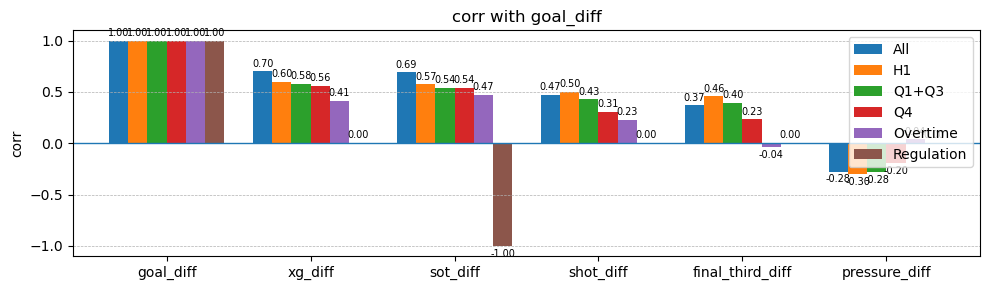

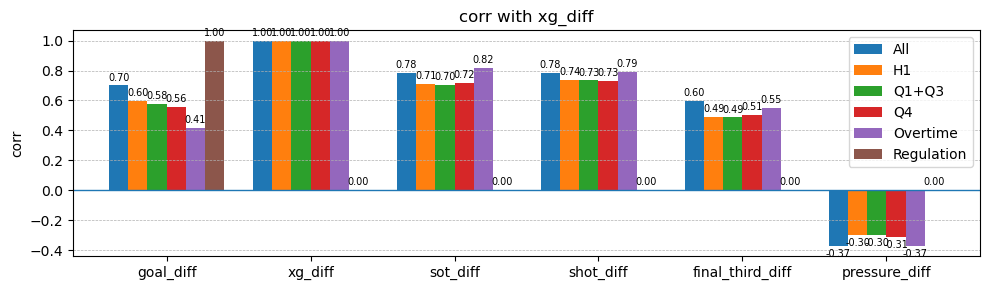

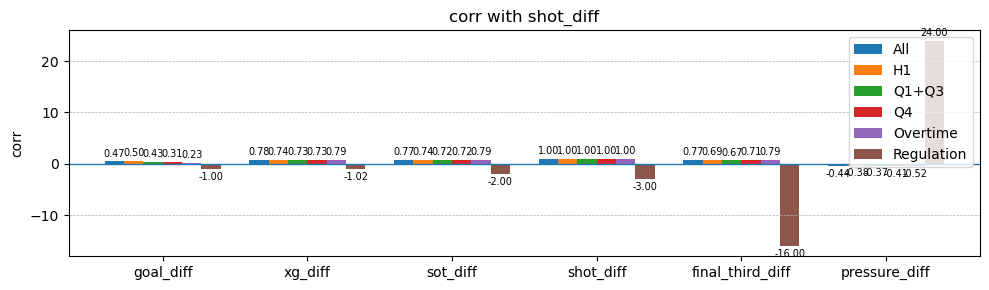

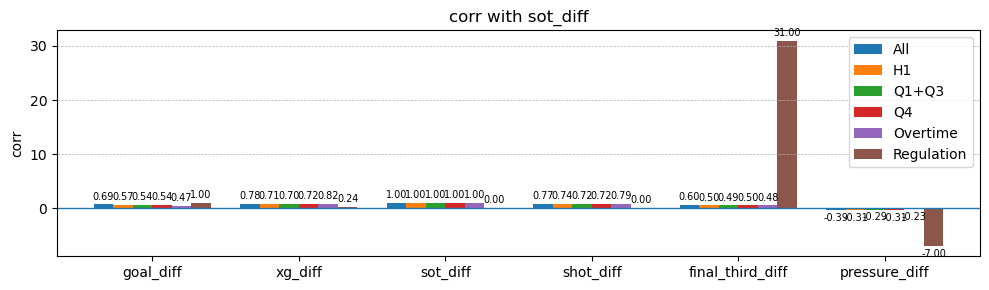

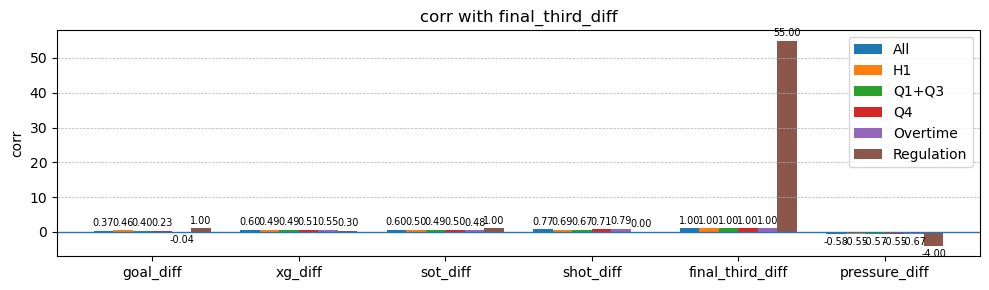

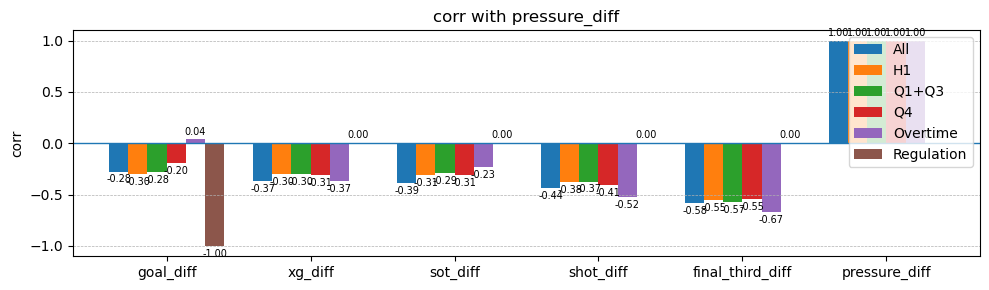

In [13]:
# === APPLY corr_series() TO FILTERED DFs ===
# -------------------------------------------------------------------
# calls correlation function across filtered dfs
# -------------------------------------------------------------------
corr_dfs = {"All": corr_df,"H1": corr_df_h1,"Q1+Q3": corr_df_q1_q3,"Q4": corr_df_q4,"Overtime": corr_df_ot, "Regulation": df_reg}

plot_corrs(["goal_diff","xg_diff","shot_diff","sot_diff","final_third_diff","pressure_diff"],corr_dfs,magnitude=False)
# plot_corrs(["goal_diff"],corr_dfs,magnitude=False)

# NOTE TO NICK
## CORRELATION INTERPRETATION COMMENTARY DOES NOT ACCOUNT FOR df_ref CORRELATIONS

### INTERPRETATION: Correlations with time windows
- xG difference is the most stable predictor across time windows
- Shots on target difference is nearly as strong
- Shot volume is weaker and decays late: Shot diff drops sharply in Q4 and OT => Late-game shot volume likely becomes game-state driven (losing teams shoot more)
- Final third entries are moderate but unstable: Reasonable early (0.46 H1), but weak or useless in Q4 and OT
- Pressure diff is negatively correlated, but weaker. The negative correlation likely means teams that are trailing press more.
#### Time Window Signal Strength
- Signal strength ordering (goal_diff correlation): Full match > First half > Q1+Q3 > Q4 > OT
- This suggests that predictive modeling BEFORE the game ends: H1 signals are viable, Q1+Q3 are viable, Q4 is unstable, OT is very noisy
| H1 | Q1+Q3 | Q4 | OT |
| :--- | :--- | :--- | :--- |
| Viable | Viable | Unstable | Noisy |
#### Multicollinearity Warning
- xg_diff ↔ shot_diff = 0.78
- xg_diff ↔ sot_diff = 0.78
- shot_diff ↔ sot_diff = 0.77
- shot_diff ↔ final_third_diff = 0.77
Thus, modeling should use only xg_diff, or perform PCA.
#### Most Interesting Modeling Insight from Overtime correlations
- final_third_diff and pressure_diff both are nearly 0
- So in overtime, only shot quality and SOT matter. Territory and pressure completely collapse.
#### Clear Takeaways
1. xG difference is the cleanest and most consistent strength proxy.
2. SOT difference is surprisingly strong.
3. Territory is an early predictor but fades late.
4. Pressure is reactive, not predictive.
5. Overtime is noisy and structurally different.

--------

--------

## 3.2. Initial Modeling

### Setup, Simplification and Assumptions
**Starting with only win/loss and regulation time**
* drops draws rows: results in perfect balance (# wins = # losses) which is ideal for logistic regression — no class imbalance, no weighting needed
* only include events occurring in regulation: later periods, especially overtime, were extra noisy

**Data Structure Notes (by design) and Model Assumptions**

When looking at differences, and means of differences, they are symmetric (i.e., mean_xg_diff is equal magnitudes for wins and losses, and the overall mean is 0). This because for every positive expected goal different, their opponent has an equal but negative xG difference. We see that:
- Distribution is symmetric around 0.
- Interquartile range ≈ 1.90.
- The class means (±0.917) are almost exactly at the 25th and 75th percentiles.

And this implies:
- If xg_diff > 0, probability of winning should exceed 0.5.
- If xg_diff < 0, probability should drop below 0.5.
- Logistic curve should be smooth and well-behaved.

In [14]:
# === CUSTOM FUNCTION TO SAVE MODEL PERFORMANCE METRICS FOR LATER COMPARISON ===
def cv_metrics(acc_scores, auc_scores, model_name):
    return pd.DataFrame([{
        "model": model_name,
        "acc_mean": np.mean(acc_scores),
        "acc_std":  np.std(acc_scores),
        "auc_mean": np.mean(auc_scores),
        "auc_std":  np.std(auc_scores),
    }]).round(3)

## Model 1
#### Simple Logistic Regression with one predictor (xg_diff only)
----------

## Regulation time data inspection

In [23]:
# events_reg = events_df.filter(((pl.col("period") <= 2)))
print("events_reg :", events_reg.shape)
print("df_reg before recreating:", df_reg.shape)
df_reg = create_match_results_matrix(events_reg, match_results) 
print("df_reg after recreating :", df_reg.shape)

events_reg : (12134916, 112)
match summary dataframe shape: (6928, 36)
df_reg     : (6928, 36)


In [24]:
# === CREATE df_reg_binary DF ===
df_reg_binary = (df_reg
    .filter(pl.col("result").is_in(["Win", "Loss"]))
    .with_columns((pl.col("result") == "Win").cast(pl.Int8).alias("win")))
display(df_reg_binary.select([pl.col("xg_diff").mean().alias("mean_xg_diff"),pl.col("xg_diff").std().alias("std_xg_diff")]))
display(df_reg_binary.group_by("win").agg(pl.col("xg_diff").mean().alias("mean_xg_diff")))
display(df_reg_binary.select(
    pl.col("xg_diff").quantile(0.25).alias("xG Diff q0.25"),
    pl.col("xg_diff").quantile(0.5).alias("xG Diff q0.50"),
    pl.col("xg_diff").quantile(0.75).alias("xG Diff q0.75")
))

mean_xg_diff,std_xg_diff
f32,f32
2.6460e-10,1.486408


win,mean_xg_diff
i8,f32
0,-0.916865
1,0.916865


xG Diff q0.25,xG Diff q0.50,xG Diff q0.75
f32,f32,f32
-0.952118,0.000411,0.952118


### Interpretation of Regulation Time events
When looking at differences, and means of differences, they are symmetric (i.e., mean_xg_diff is equal magnitudes for wins and losses, and the overall mean is 0). This because for every positive expected goal different, their opponent has an equal but negative xG difference. We see that:
- Distribution is symmetric around 0.
- Interquartile range ≈ 1.90.
- The class means (±0.917) are almost exactly at the 25th and 75th percentiles.

And this implies:
- If xg_diff > 0, probability of winning should exceed 0.5.
- If xg_diff < 0, probability should drop below 0.5.
- Logistic curve should be smooth and well-behaved.

In [25]:
# Prepare X and y
X = df_reg_binary.select("xg_diff").to_numpy()
y = df_reg_binary.select("win").to_numpy().ravel()

In [26]:
# === LR MODEL | ONE FEATURE, REGULATION TIME ONLY ===
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Fit logistic regression
model = LogisticRegression()
model.fit(X, y)

# Extract coefficients
beta_0 = model.intercept_[0]
beta_1 = model.coef_[0][0]

print("  Intercept (Beta_0):", round(beta_0, 2))
print("Coefficient (Beta_1):", round(beta_1, 2))

# accuracy and AUC
probs = model.predict_proba(X)[:,1]
preds = model.predict(X)

accuracy = accuracy_score(y, preds)
auc = roc_auc_score(y, probs)

accuracy, auc
print("            Accuracy:", round(accuracy, 2))
print("                 AUC:", round(auc, 2))

  Intercept (Beta_0): -0.0
Coefficient (Beta_1): 1.53
            Accuracy: 0.79
                 AUC: 0.88


### Intepretation of Regulation Time LogReg Model
- Intercept: $ \beta_0 = 0 \implies P(\text{Win} \mid xg\_diff = 0) = 0.5 $
- Slope: $ \beta_1 = 1.53 \implies$ for every +1.0 increase in xG differential  $ \text{log-odds increase by } 1.53 \implies \exp(1.53) \approx 4.62$
> So each additional +1 xG advantage multiplies the odds of winning by about 4.6x.

### Probability interpretation
Mean xg_diff for wins is 0.9169

$ \quad \implies \text{logit} = 1.53 \times 0.9169 = 1.40 $

$ \quad \implies  P(\text{Win}) = \frac{1}{1 + e^{-1.40}} \approx 0.80 $

So at the average winning xG differential, the model predicts about an 80% chance of winning. This is extremely reasonable. 

In [27]:
# === CROSS VALIDATION LR MODEL | ONE FEATURE, REGULATION TIME ONLY ===
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
model = LogisticRegression()
# Accuracy
acc_scores = cross_val_score(model, X, y, cv=10, scoring="accuracy")
# AUC
auc_scores = cross_val_score(model, X, y, cv=10, scoring="roc_auc")
print("=== CROSS VALIDATION MODEL RESULTS ===\n")
print("ACC Mean = ", round(np.mean(acc_scores), 3), "ACC STD = ", round(np.std(acc_scores), 3))
print("AUC Mean = ", round(np.mean(auc_scores), 3), "AUC STD = ", round(np.std(auc_scores), 3))
logreg_cv_results = cv_metrics(acc_scores, auc_scores, "LogReg: xg_diff")
display(logreg_cv_results)

=== CROSS VALIDATION MODEL RESULTS ===

ACC Mean =  0.788 ACC STD =  0.044
AUC Mean =  0.873 AUC STD =  0.04


,model,acc_mean,acc_std,auc_mean,auc_std
0,LogReg: xg_diff,0.788,0.044,0.873,0.04


Standard deviations are small, meaning:
- The model generalizes well.
- Performance does not swing wildly across folds.
- xg_diff is a consistent predictor, not sample noise.

Accuracy is approx. 78.8%. With a baseline of 50%, thats a +28.8 percentage points from using just one feature. AUC of 0.87 indicates a very strong model. 

## Model 2
### Logistic Regression with variable selection (forward search BIC)
* We will use BIC rather than AIC as we are investigating model selection, rather than aiming to improve predictive accuracy. BIC also penalizes model complexity more strongly than AIC, which is favorable at this stage in the EDA.
* Due to high multicollinearity and derived variable, we are initially only using differential features. For example, we use pass_diff, but not n_passes, passes_against, etc.
* we are also not using goal_diff, as that is the realized outcome
* **NEXT STEP: Train a model on full regulation match summaries. Then evaluate how predictive early-game summaries are of final result.**
> Approach A — Train & Test on Early-Only Data;Approach B — Train on Full Game Model, Test on Early Features

-------

In [28]:
# Candidate predictors
candidates = ["shot_diff","sot_diff","final_third_diff","pressure_diff","carry_diff","dribble_diff","pass_diff","pass_complete_diff",]

X_full = df_reg_binary.select(candidates).to_pandas()
y = df_reg_binary.select("win").to_pandas().values.ravel()

In [29]:
# === FORWARD SEARCH LR MODEL | DIFFERENTIAL PREDICTORS ONLY | REGULATION TIME ===
import statsmodels.api as sm

def compute_bic(X, y):
    X_const = sm.add_constant(X)
    model = sm.Logit(y, X_const).fit(disp=False)
    return model.bic, model

selected = []
remaining = candidates.copy()
current_bic = np.inf

print("Starting Forward Selection (BIC)\n")

while len(remaining) > 0:
    
    bic_with_candidates = []
    
    for candidate in remaining:
        X_candidate = X_full[selected + [candidate]]
        bic, _ = compute_bic(X_candidate, y)
        bic_with_candidates.append((bic, candidate))
    
    bic_with_candidates.sort()
    best_bic, best_candidate = bic_with_candidates[0]
    
    if best_bic < current_bic:
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_bic = best_bic
        print(f"Added: {best_candidate} | BIC: {round(best_bic, 2)}")
    else:
        break

print("\nFinal selected variables (diff features only, no xg_diff):", selected)

Starting Forward Selection (BIC)

Added: sot_diff | BIC: 4684.98
Added: shot_diff | BIC: 4580.92
Added: carry_diff | BIC: 4577.77
Added: pass_diff | BIC: 4533.81
Added: pass_complete_diff | BIC: 4303.24

Final selected variables (diff features only, no xg_diff): ['sot_diff', 'shot_diff', 'carry_diff', 'pass_diff', 'pass_complete_diff']


In [30]:
# === FORWARD SEARCH LR MODEL | ALL PREDICTORS | REGULATION TIME ===
import statsmodels.api as sm
import numpy as np

# Candidate predictors
candidates = [
    'shots', 'shots_on_target', 'pressures', 'final_third_passes', 'final_third_carries', 'n_carries', 'n_dribbles', 'n_passes', 'n_passes_complete', 'final_third_entries', 
    'shots_against', 'sot_against', 'final_third_against', 'pressure_against', 'shot_diff', 'sot_diff', 'final_third_diff', 'pressure_diff', 'pass_completion_rate', 
    'carries_against', 'dribbles_against', 'passes_against', 'passes_complete_against', 'carry_diff', 'dribble_diff', 'pass_diff', 'pass_complete_diff']

X_full = df_reg_binary.select(candidates).to_pandas()
y = df_reg_binary.select("win").to_pandas().values.ravel()

def compute_bic(X, y):
    X_const = sm.add_constant(X)
    model = sm.Logit(y, X_const).fit(disp=False)
    return model.bic, model

selected = []
remaining = candidates.copy()
current_bic = np.inf

print("Starting Forward Selection (BIC)\n")

while len(remaining) > 0:
    
    bic_with_candidates = []
    
    for candidate in remaining:
        X_candidate = X_full[selected + [candidate]]
        bic, _ = compute_bic(X_candidate, y)
        bic_with_candidates.append((bic, candidate))
    
    bic_with_candidates.sort()
    best_bic, best_candidate = bic_with_candidates[0]
    
    if best_bic < current_bic:
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_bic = best_bic
        print(f"Added: {best_candidate} | BIC: {round(best_bic, 2)}")
    else:
        break

print("\nFinal selected variables (all features, no xg diff, for, against, etc.):", selected)

Starting Forward Selection (BIC)

Added: sot_diff | BIC: 4684.98
Added: shot_diff | BIC: 4580.92
Added: carry_diff | BIC: 4577.77
Added: pass_diff | BIC: 4533.81
Added: pass_complete_diff | BIC: 4303.24

Final selected variables (all features, no xg diff, for, against, etc.): ['sot_diff', 'shot_diff', 'carry_diff', 'pass_diff', 'pass_complete_diff']


### Interpretation
Interesting to see the forward search algorithm choose sot_diff before xg_diff. This is because BIC favors simpler models, meaning sot_diff is slightly better in likelihood-to-penalty tradeoff. 

Also, the three features selected are all highly correlation (>0.7 to each other). Even correlated predictors can add incremental likelihood improvements if they capture slightly different aspects. This result is promising for the possible performance of a PCA model. 

When including all variables, the same result is achieved. 

In [31]:
# === LR MODEL PERFORMANCE | FORWARD SEARCH PREDICTORS | REGULATION TIME ===
features_selected = ["sot_diff", "xg_diff", "shot_diff"]

X_sel = df_reg_binary.select(features_selected).to_numpy()
y = df_reg_binary.select("win").to_numpy().ravel()

model = LogisticRegression()

acc_scores2 = cross_val_score(model, X_sel, y, cv=5, scoring="accuracy")
auc_scores2 = cross_val_score(model, X_sel, y, cv=5, scoring="roc_auc")

logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_scores2, auc_scores2, "LogReg: sot_diff + xg_diff + shot_diff")
], ignore_index=True).drop_duplicates()

logreg_cv_results

,model,acc_mean,acc_std,auc_mean,auc_std
0,LogReg: xg_diff,0.788,0.044,0.873,0.04
1,LogReg: sot_diff + xg_diff + shot_diff,0.843,0.027,0.922,0.02


#### Interpretation
This is a substantial jump, meaning shot volume and SOT add real incremental predictive signal, even with xg_diff alone being very strong. 

#### Why does this make sense?
xg captures shot quality, but it does not capture shot frequency dominance, finishing precision (SOT), or situations where volume matters over quality. 

## Model 3: PCA -> choose top k predictors -> Logistic Regression
* we use all possible predictors, as PCA will resolve any redundancy 

In [32]:
# === PCA LR MODEL | ALL PREDICTORS | REGULATION TIME ===
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd
# -------------------------------------------------
# 1. Select all numeric predictors except target
# -------------------------------------------------

feature_cols = [
    'shots', 'xg_for', 'shots_on_target', 'pressures', 'final_third_passes', 'final_third_carries', 'n_carries', 'n_dribbles', 'n_passes', 'n_passes_complete', 'final_third_entries', 
    'shots_against', 'sot_against', 'xg_against', 'final_third_against', 'pressure_against', 'shot_diff', 'sot_diff', 'xg_diff', 'final_third_diff', 'pressure_diff', 'pass_completion_rate', 
    'carries_against', 'dribbles_against', 'passes_against', 'passes_complete_against', 'carry_diff', 'dribble_diff', 'pass_diff', 'pass_complete_diff']

X_raw = df_reg_binary.select(feature_cols).to_pandas()
y = df_reg_binary["win"].to_numpy()

# -------------------------------------------------
# 2. Standardize
# -------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# -------------------------------------------------
# 3. Fit PCA
# -------------------------------------------------

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# -------------------------------------------------
# 4. Explained variance
# -------------------------------------------------

explained_variance = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance.head(10)

,PC,Explained Variance Ratio,Cumulative Variance
0,1,0.563345,0.563345
1,2,0.088976,0.652321
2,3,0.064562,0.716883
3,4,0.046812,0.763695
4,5,0.046154,0.809849
5,6,0.040391,0.850240
6,7,0.033542,0.883782
7,8,0.026786,0.910568
8,9,0.023857,0.934425
9,10,0.016075,0.950501


### Intepretation
* PC1 dominates, explaining 56% of the variance. PC2 adds about 9%

#### Now we run logistic regression on the top k principal components

,n_components,acc_mean,auc_mean
0,1,0.682,0.748
1,2,0.766,0.849
2,3,0.766,0.849
3,4,0.771,0.854
4,5,0.780,0.861
5,6,0.780,0.861
6,7,0.791,0.880
7,8,0.792,0.880
8,9,0.803,0.887
9,10,0.838,0.914


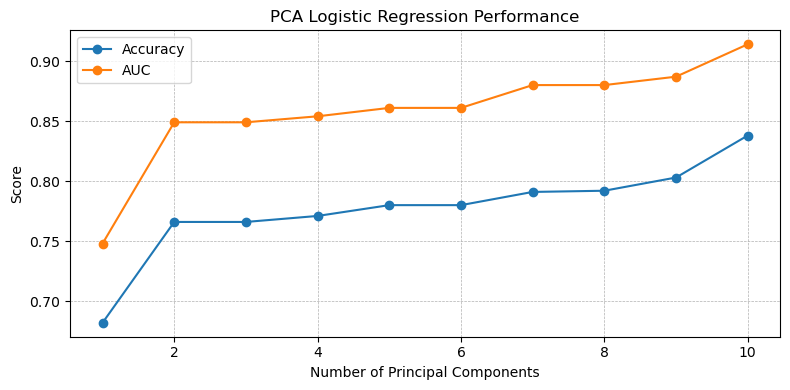

In [33]:
# === PCA LR MODEL | TOP K PCs | REGULATION TIME EVENTS
results_pca = []
for k in range(1, 11):
    X_k = X_pca[:, :k]
    model = LogisticRegression()
    acc_scores = cross_val_score(model, X_k, y, cv=5, scoring="accuracy")
    auc_scores = cross_val_score(model, X_k, y, cv=5, scoring="roc_auc")
    results_pca.append({
        "n_components": k,
        "acc_mean": np.mean(acc_scores),
        "auc_mean": np.mean(auc_scores)})

pca_results_df = pd.DataFrame(results_pca).round(3)
display(pca_results_df)

# plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pca_results_df["n_components"], pca_results_df["acc_mean"], marker='o', label="Accuracy")
ax.plot(pca_results_df["n_components"], pca_results_df["auc_mean"], marker='o', label="AUC")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Score")
ax.set_title("PCA Logistic Regression Performance")
ax.legend()
ax.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

#### Why did forward search still perform well even with highly correlated features?
- Logistic regression with regularization (L2 penalty) is stable under multicollinearity and primarily optimized for prediction, not inference. So it does not necessarily harm prediction.
- But, collinearity does harm coefficient interpretability, standard errors, and inference stability. 
#### Why PCA avoids this
- PCA produces orthogonal components: PC₁ ⟂ PC₂ ⟂ PC₃ ⟂ … . No multicollinearity exists by construction.
- So, coefficients are stable and dimensions are independent. 
#### The Real Tradeoff
- Forward Search Model: 3 variables, interpretable, collinear, AUC ≈ 0.922
- PCA Model: 7–10 components, hard to interpret, orthogonal, AUC ≈ 0.914

**Key insight**: Multicollinearity is not hurting predictive performance in this case. However, it would matter for hypothesis testing and interpretion of coefficient magnitudes. But here we are optimizing prediction.

## Model 4: Logistic Regression on first half data only
--------
* this will help simulate live game prediction. It is answering the question "can we predict end game result based on events seen in the first half alone?"

In [34]:
print("events_reg       :", events_first_half.shape)
# df_first_half = create_match_results_matrix(events_first_half, match_results) 
df_first_half_binary = (df_h1
    .filter(pl.col("result").is_in(["Win", "Loss"]))
    .with_columns((pl.col("result") == "Win").cast(pl.Int8).alias("win")))

features_selected = ["sot_diff", "xg_diff", "shot_diff"]

X_sel = df_first_half_binary.select(features_selected).to_numpy()
y = df_first_half_binary.select("win").to_numpy().ravel()


events_reg       : (6139005, 112)


In [35]:
### Run and test model with the 3 predictors ###
model = LogisticRegression()

acc_scores4 = cross_val_score(model, X_sel, y, cv=5, scoring="accuracy")
auc_scores4 = cross_val_score(model, X_sel, y, cv=5, scoring="roc_auc")

logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_scores4, auc_scores4, "LogReg H1: sot_diff + xg_diff + shot_diff")
], ignore_index=True).drop_duplicates()

logreg_cv_results

,model,acc_mean,acc_std,auc_mean,auc_std
0,LogReg: xg_diff,0.788,0.044,0.873,0.040
1,LogReg: sot_diff + xg_diff + shot_diff,0.843,0.027,0.922,0.020
2,LogReg H1: sot_diff + xg_diff + shot_diff,0.766,0.029,0.841,0.038


### Interpretation
- from earlier correlations, full game yeilded `corr(goal_diff, xg_diff) ≈ 0.70`. The for the first half, it dropped `corr(goal_diff, xg_diff) ≈ 0.59`. So the drop in predictive power (AUC dropped from 0.922 → 0.841) matches the correlation weakening.
- Full-game shot-based metrics predict outcome extremely well (AUC ≈ 0.92). Using only first-half information, prediction remains strong (AUC ≈ 0.84), indicating that early match dominance is highly informative but not decisive.

## Model 5: The frozen model (Testing the best model)
* train the model on a full set of data (full game) and then test it by feeding it only data from the first half to see how well it predicts.
* Note: the model training uses all data, and no CV is performed.
-------

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

features_selected = ["sot_diff", "xg_diff", "shot_diff"]

# Full-game training data
X_full = df_reg_binary.select(features_selected).to_numpy()
y_full = df_reg_binary.select("win").to_numpy().ravel()

# Fit model once on ALL full-game data
model_full = LogisticRegression()
model_full.fit(X_full, y_full)

### === TEST === ###
# First-half features
X_h1 = df_first_half_binary.select(features_selected).to_numpy()
y_h1 = df_first_half_binary.select("win").to_numpy().ravel()

# Predict probabilities using full-game-trained model
y_pred_prob = model_full.predict_proba(X_h1)[:, 1]
y_pred_class = model_full.predict(X_h1)

# Compute metrics
acc_h1_frozen = accuracy_score(y_h1, y_pred_class)
auc_h1_frozen = roc_auc_score(y_h1, y_pred_prob)

acc_h1_frozen, auc_h1_frozen

logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_h1_frozen, auc_h1_frozen, "LogReg Frozen: sot_diff + xg_diff + shot_diff")
], ignore_index=True).drop_duplicates()

logreg_cv_results

,model,acc_mean,acc_std,auc_mean,auc_std
0,LogReg: xg_diff,0.788,0.044,0.873,0.040
1,LogReg: sot_diff + xg_diff + shot_diff,0.843,0.027,0.922,0.020
2,LogReg H1: sot_diff + xg_diff + shot_diff,0.766,0.029,0.841,0.038
3,LogReg Frozen: sot_diff + xg_diff + shot_diff,0.736,0.000,0.818,0.000


### Interpretation
- Main observation: ACC and AUC dropped slightly compared to model 4 (which was trained AND tested on H1 data only). Why?
- First-half shot/xG patterns are noisier than second-half dynamics. Some matches flip late. The retrained H1 model slightly adjusts coefficient magnitudes to account for early volatility. The frozen model assumes full-game linear structure holds perfectly.
- However, the drop is not large, indicating impressive stability. That means the relationship between event dominance and final win probability is largely time-invariant.